In [1]:
import numpy as np
from pathlib import Path
import os, sys
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
import warnings
import pandas as pd

repo_root = Path("/home/thardy/elefanto/ConsciousnessTeam_Data/SOUNDMODEL/Data_SoundGOOD/LEAD_ExperimentalFolder")
os.chdir(repo_root)

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))
os.environ["PYTHONPATH"] = str(repo_root) + os.pathsep + os.environ.get("PYTHONPATH", "")

import LEAD as lead


# Important variables
cwd = Path.cwd()
SNRs = np.array([-np.inf,-13,-11,-9,-7,-5,-3])
SubIDs = ['01','02','03','05','06','07','08','09','11','12','13','14','15','17','19','20','22','23','24','25']
colormap = {0: (0, 0, 0), 1: (0, 0.25, 1), 2: (0, 0.9375, 1), 3: (0, 0.91, 0.1), 4: (1, 0.6, 0), 5: (1, 0, 0), 6: (0.8, 0, 0)}

In [2]:
def count_sign_changes(delta_x):
    signs = np.sign(delta_x)
    sign_changes = np.sum(np.diff(signs) != 0)
    return sign_changes

def is_bifurcation(delta_x_list):
    counts = [count_sign_changes(delta_x) for delta_x in delta_x_list]
    unique_counts = set(counts)
    return len(unique_counts) > 1


# Bifurcation Probability via Particle Density Estimation

{0: 0.0, 1: 4.545029324903367e-05, 2: 5.0091758573991895e-08, 3: 2.0114321554299014e-05, 4: 0.0003714454179454, 5: 0.0, 6: 0.999999600113228, 7: 0.0, 8: 0.0, 9: 0.9971541539739512, 10: 8.18167563414243e-06, 11: 1.0842601920163898e-20, 12: 0.0125772786555076, 13: 0.9822691002138656, 14: 0.7793844921507868, 15: 0.0, 16: 0.0, 17: 0.0, 18: 0.4521836680445799, 19: 5.044954415609576e-05}
Plotting for Threshold: 0.9873628402697927, Tau: 5.157728886402598


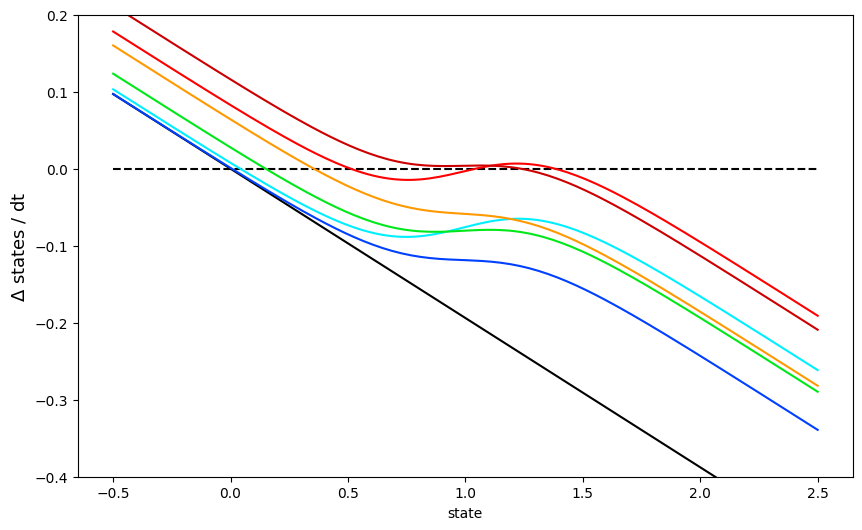

Plotting for Threshold: 0.25, Tau: 5


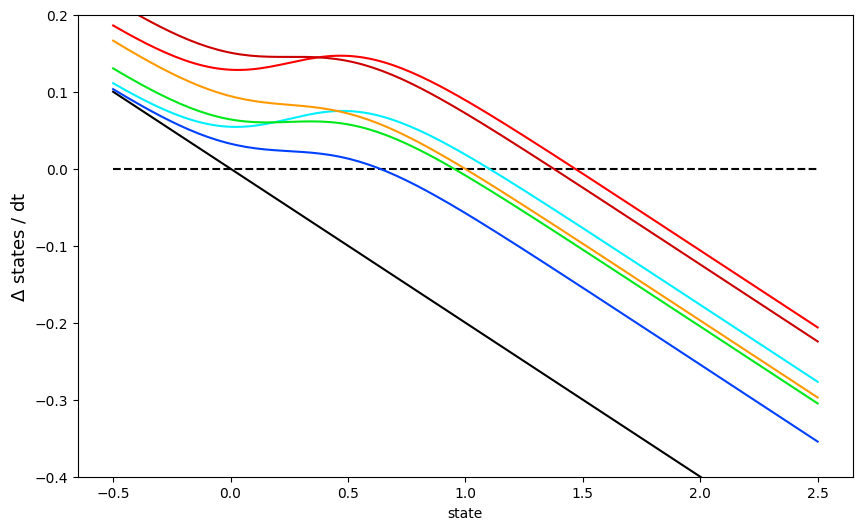

Plotting for Threshold: 0.85, Tau: 5.55


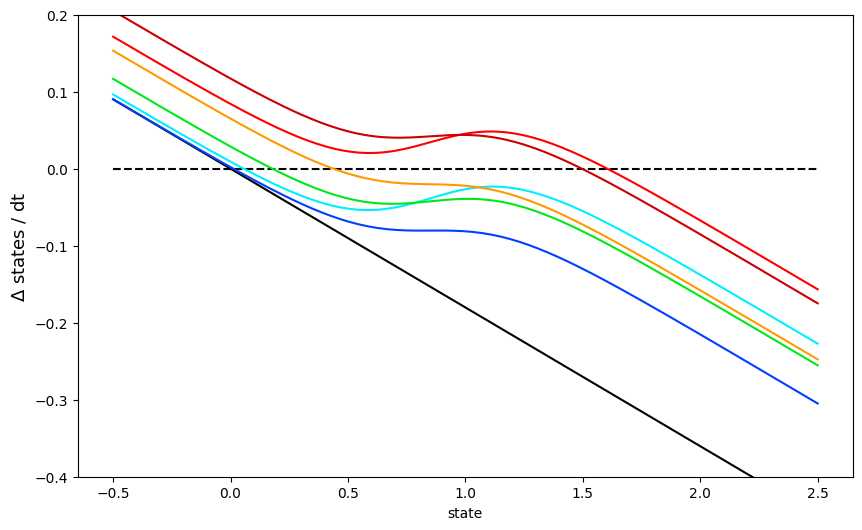

Plotting for Threshold: 1.5, Tau: 5.4


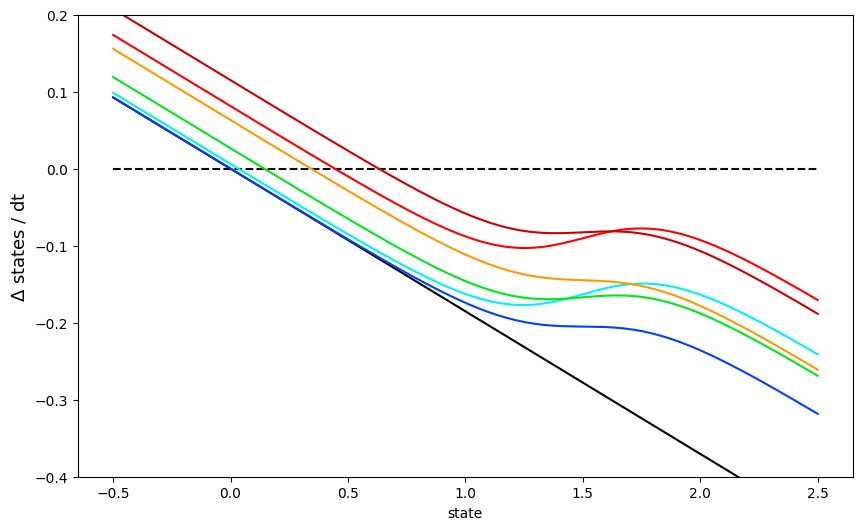

Plotting for Threshold: 1.9, Tau: 4.8


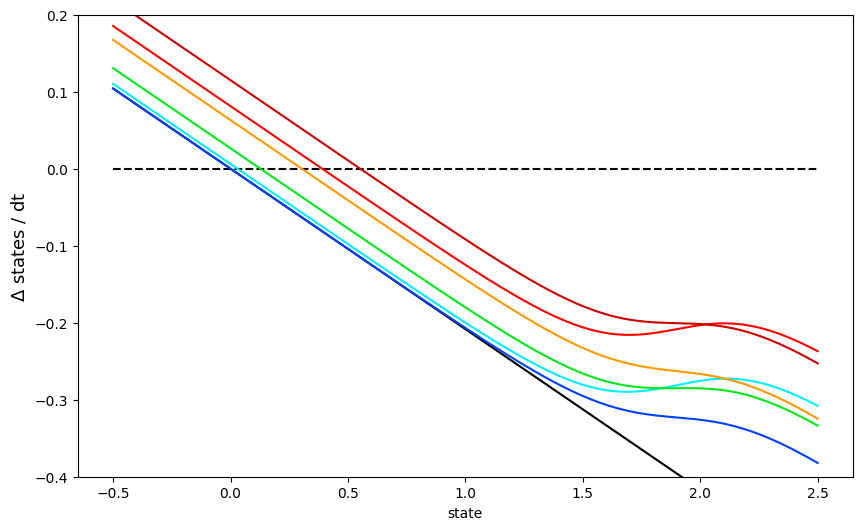

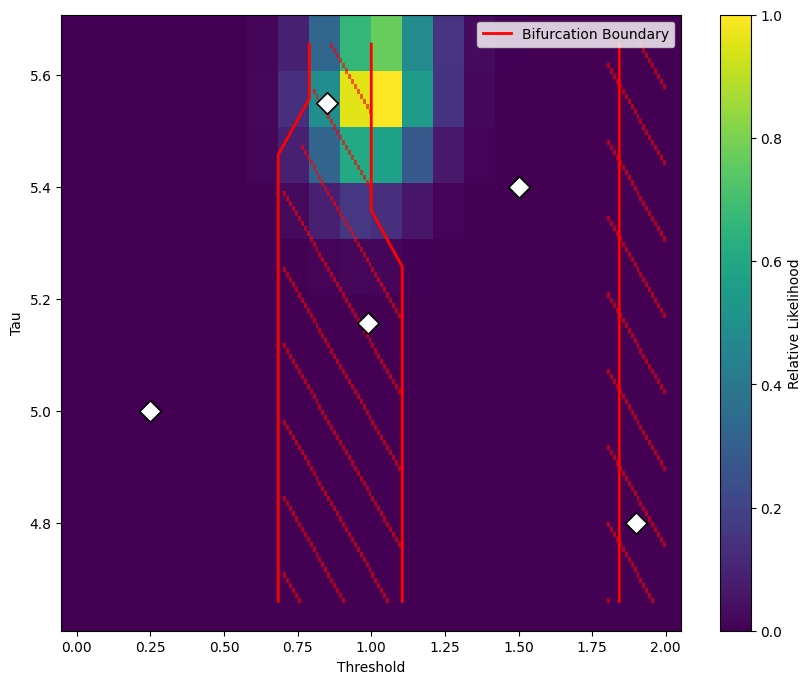

In [25]:
task = "Passive"
file_path = Path(f'Fit_{task}_late')
sub_file_path = "BifurcationProbability_WholeGrid"

# Define the summary path clearly and load existing progress 
summary_path = file_path / sub_file_path / "bifurcation_probabilities.csv"
existing_df = pd.read_csv(summary_path, index_col=0)
bifurcation_prob = existing_df["probability_of_bifurcation"].to_dict()
print(bifurcation_prob)

    
for part in [18]: #range(20):

    
    # --- Load Parent Parameters ---
    gainmodul_parent = lead.model.StratifiedGainModulation(
        tau=10, process_noise=0.1, measure_noise=0.1, threshold=1, sharpness=5)
    param_path = file_path / f"GainModulatedModel_part{part}_params"
    gainmodul_parent.load_params(param_path)

    # Plot selected model samples 
    # TODO: For each couple chosen for the diamonds, also fit the gain and the input_weigths !!
    diamond_points = [(gainmodul_parent.threshold, gainmodul_parent.tau), 
                      (0.25, 5), (0.85, 5.55), (1.5, 5.4), (1.9, 4.8)]  # (threshold, tau); edit these coordinates as needed
    states = np.linspace(-0.5, 2.5, 150)
    conditions = [(0, 0), (1, 1), (1,2), (1,3), (1,4), (1,5), (1,6)]
    labels = {cat: str(cat) for cat in range(7)}
    for threshold, tau in diamond_points:
        print(f"Plotting for Threshold: {threshold}, Tau: {tau}")
        gainmodul_parent.threshold = threshold
        gainmodul_parent.tau = tau
        model_func = gainmodul_parent.core
        plt.figure(figsize=(10, 6))
        plt.plot([states[0], states[-1]], [0, 0], linestyle='--', color='black')
        for cond_ind, (input_value, signal_category) in enumerate(conditions):
            plt.plot(
                states,
                model_func(states, input_value * np.ones_like(states), signal_category) - states,
                color=colormap[cond_ind],
                label=labels[cond_ind])
        plt.xlabel('state')
        plt.ylabel(r'$\Delta$ states / dt', fontsize=13)
        plt.ylim((-0.4, 0.2))
        plt.show()

    # Load Results
    loaded = np.load(file_path / sub_file_path / f"2D_grid_search_part{part}.npz")
    thresh_range = loaded["threshold_range"]
    tau_range = loaded["tau_range"]
    ll_array = loaded["ll"]
    likelihood = loaded["likelihood"]
    bif_array = loaded["bifbool"]


    # --- Plotting (2D Heatmap with Contours) ---
    plt.figure(figsize=(10, 8))
    
    # Create 2D Meshgrid for plotting
    # thresh_range (x-axis), tau_range (y-axis)
    X, Y = np.meshgrid(thresh_range, tau_range)
    
    # 1. Plot Heatmap of Likelihood
    # Using pcolormesh for the heatmap
    pcm = plt.pcolormesh(X, Y, likelihood, shading='auto', cmap='viridis')
    plt.colorbar(pcm, label='Relative Likelihood')
    
    bif_hatch_spacing = 15  # Increase for sparser diagonal lines, decrease for a denser fill
    bif_hatch_thickness = 1  # Increase for thicker stripes, decrease for thinner stripes
    bif_hatch_scale = 10  # Increase to make the overlay pattern visibly smoother

    # Plot Contour of Bifurcation Boundary
    # We draw a line at 0.5 (since bif_array is 0 or 1) to show the border
    # colors='red' makes the bifurcation line distinct
    if np.any(bif_array) and not np.all(bif_array):
        hatch_mask = np.repeat(np.repeat(bif_array.astype(bool), bif_hatch_scale, axis=0), bif_hatch_scale, axis=1)
        hatch_rows, hatch_cols = hatch_mask.shape
        hatch_pattern = (np.add.outer(np.arange(hatch_rows), np.arange(hatch_cols)) % bif_hatch_spacing) < bif_hatch_thickness
        hatch_overlay = np.zeros((hatch_rows, hatch_cols, 4))
        hatch_overlay[..., 0] = 1.0
        hatch_overlay[..., 3] = np.where(hatch_mask & hatch_pattern, 0.6, 0.0)
        plt.imshow(
            hatch_overlay,
            extent=[thresh_range.min(), thresh_range.max(), tau_range.min(), tau_range.max()],
            origin='lower',
            aspect='auto',
            zorder=3,
            interpolation='nearest',
        )
        diamond_thresholds, diamond_taus = zip(*diamond_points)
        plt.scatter(
            diamond_thresholds,
            diamond_taus,
            marker='D',
            s=120,
            facecolors='white',
            edgecolors='black',
            linewidths=1.2,
            zorder=4,
        )
        CS = plt.contour(X, Y, bif_array, levels=[0.5], colors='red', linewidths=2)
        # Create a proxy artist for the legend
        from matplotlib.lines import Line2D
        proxy_line = Line2D([0], [0], color='red', linewidth=2, label='Bifurcation Boundary')
        plt.legend(handles=[proxy_line], loc='upper right')
    elif np.all(bif_array):
        plt.title(f"Part {part} (All Bifurcation)")
    else:
        plt.title(f"Part {part} (No Bifurcation)")

    # plt.title(f'Parameter Space: Tau vs Threshold - Part {part}\nWeighted Bifurcation Prob: {proba:.3f}')
    plt.xlabel('Threshold')
    plt.ylabel('Tau')
    
    # Save plot
    # plt.savefig(file_path / sub_file_path / f"2D_likelihood_part{part}_{task}.png")
    plt.show()